In [87]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.plotting.plotter_localization import PlotterLocalization
from odometry.point_cloud_processing.vel_filtering import VelFiltering
from odometry.plotting.movies import MovieGenerator
import cv2

In [88]:
dataset = radnavDS(
    dataset_path="/data/radnav/rad_nav_filter_experiments/WILK_SPEED_1_WALK/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="wilkinson.yaml"
)

plotter = PlotterLocalization(dataset,map_handler)

found 2196 radar samples
found 2196 lidar samples
found 2196 camera samples
found 2196 imu (orientation only) samples
found 2196imu (full data) samples
found 2196 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml


(480, 640, 3)
480 640


  0%|          | 0/2195 [00:00<?, ?it/s]

 15%|█▌        | 339/2195 [00:28<02:35, 11.92it/s]


KeyboardInterrupt: 

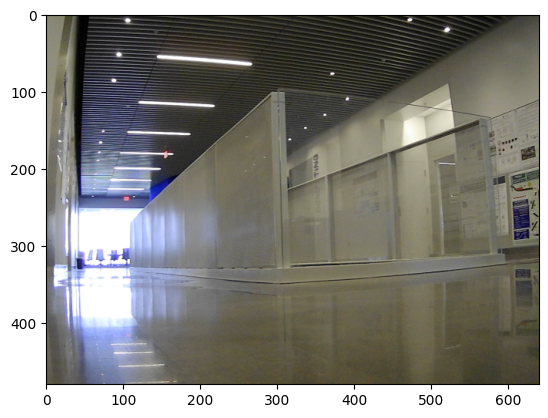

In [89]:
# idx = 1000
# img = dataset.get_camera_frame(idx)
# length, width, layers = img.shape
# print(np.shape(img))
# plt.imshow(img)
# print(length, width)
# size = (width, length)
# out = cv2.VideoWriter('output.mp4',cv2.VideoWriter_fourcc(*'mp4v'), 10, (480, 640))
# for i in tqdm(range(dataset.num_frames-1)):
#     img = dataset.get_camera_frame(i)
#     plt.imsave('img.png',img)
#     img = cv2.imread('img.png')
#     out.write(img)
#     #print(i)
# out.release

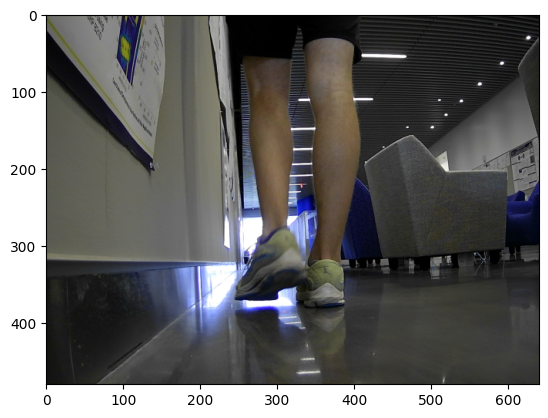

In [118]:
idx = 400
plt.imshow(
                dataset.get_camera_frame(idx)
)

0.1492611545836553
(54, 4)


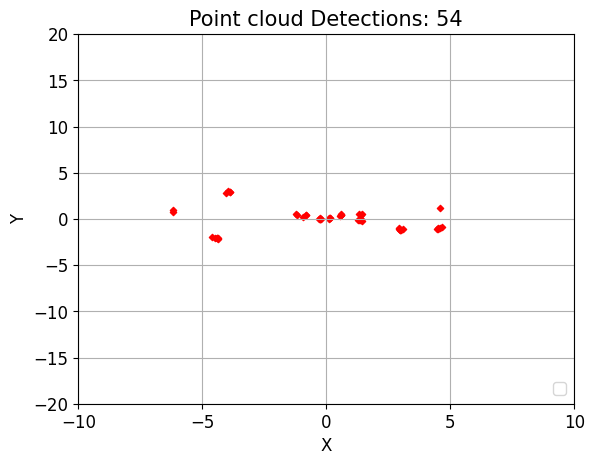

In [119]:
#get the point cloud
ego_x_vel = dataset.get_vehicle_vel_data(idx)[0,1]
vehicle_vel = np.array([ego_x_vel,0.0])
print(ego_x_vel)

#get the detections
detections = dataset.get_radar_detections(idx)
print(detections.shape)

#plot the detections
plotter.plot_detections(detections, show=True)

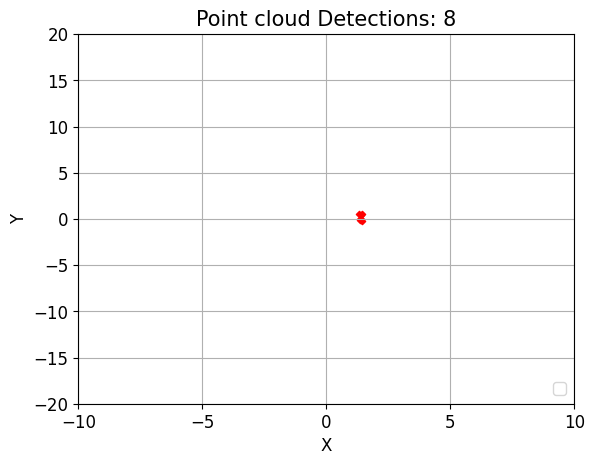

In [120]:
vel_filter = VelFiltering(v_thresh=0.4)

#plot dynamic detections
dynamic_objects = vel_filter.get_dynamic_detections(detections,vehicle_vel)
plotter.plot_detections(dynamic_objects, show=True)

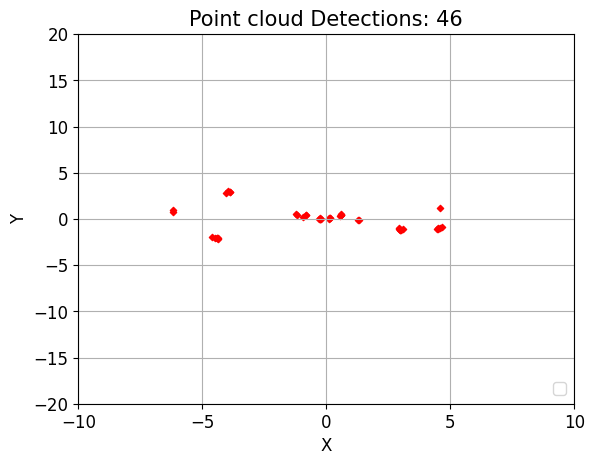

In [121]:
#plot the static objects
static_objects = vel_filter.get_static_detections(detections,vehicle_vel)
plotter.plot_detections(static_objects,show=True)

### Debugging

Useful for looking at what points are being rejected

In [111]:
#predict the velocity measurement
v_pred = vel_filter.predict_vels(detections[:,0:2],vehicle_vel)
print(v_pred)

[ 0.14343426  0.13153828  0.11924986  0.10858719  0.14654815  0.1465132
  0.14722651  0.14720448  0.14642284  0.10799426  0.14639676  0.10767886
  0.14637235  0.13116732  0.1311367   0.13110704  0.13532803  0.13531437
  0.13530105  0.13528806  0.14355472  0.14355199  0.1435493   0.14476674
  0.14583234  0.1434626   0.14346121  0.14920352  0.14902843  0.14902483
  0.13501844  0.1490232   0.1368924   0.13266995  0.14872149  0.14902658
 -0.14907305 -0.14792064 -0.14649027 -0.12776058 -0.12446372 -0.12401925
 -0.12022851 -0.11232637 -0.14387682 -0.14865516 -0.14817412 -0.14817533
 -0.14817573 -0.1481769  -0.1489216  -0.14924558 -0.14185284 -0.13477374]


In [96]:
#print the true values
v_true = detections[:,3]
print(detections.shape)
print(v_true)

(59, 4)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [14]:

errors = vel_filter.square_error_loss(v_true,v_pred)
print(errors)

[0.05361257 0.04508843 0.03705754 0.03072685 0.02596428 0.02238726
 0.0224559  0.02240371 0.02490087 0.02201059 0.02197392 0.01153802
 0.01152738 0.01151692 0.03407938 0.03407052 0.0340618  0.03404483
 0.0545554  0.05455468 0.5068862  0.50834359 0.50834275 0.50834197
 0.5083412  0.50687999 0.50687882 0.05791074 0.05701884 0.05592144
 0.05507817 0.02921742 0.02914561 0.02910995 0.02636038 0.0556413
 0.03505931 0.03506709 0.03271369 0.03270136 0.03268926 0.0302125
 0.05163871 0.05163864 0.05163856 0.05033965 0.0503318  0.05033882
 0.05033519 0.05033161 0.05032387 0.05031641 0.05031302 0.05031982
 0.04895749 0.04894604 0.04748856 0.23098806 0.22946549 0.22771986
 0.23420188 0.23419272 0.22004658 0.05804096 0.05804486 0.05243688
 0.04894754 0.18798553]
